In [5]:
!git clone https://github.com/Gopher-Industries/Guardian.git

Cloning into 'Guardian'...
Cloning into 'Guardian'...


In [16]:
cd Guardian

D:\git\Guardian


In [18]:
!git status

On branch master
Your branch is up to date with 'origin/master'.

nothing to commit, working tree clean


In [19]:
!git add .

In [3]:
!pip install torch torchvision torchaudio
!pip install numpy pandas matplotlib scikit-learn tqdm opencv-python pillow

  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached torchaudio-2.11.0-cp313-cp313-win_amd64.whl.metadata (6.9 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached torch-2.11.0-cp313-cp313-win_amd64.whl (114.6 MB)
Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl (4.3 MB)
Using cached torchaudio-2.11.0-cp313-cp313-win_amd64.whl (328 kB)
Using cached fsspec-2026.3.0-py3-none-any.whl (202 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
   -

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\User\\Miniconda\\Lib\\site-packages\\mpmath\\function_docs.py'
Consider using the `--user` option or check the permissions.



  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl (12.3 MB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.7 MB 6.9 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.7 MB 6.9 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.7 MB 6.9 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.7 MB 6.9 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.7 MB 6.9 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.7 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.7 MB 6.9 M

In [6]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
train_dir = r"D:\fer2013 + affectnet\fer2013+affectnet\train"
test_dir  = r"D:\fer2013 + affectnet\fer2013+affectnet\test"

In [7]:
train_dir = r"D:\fer2013 + affectnet\DATASET\train"
test_dir  = r"D:\fer2013 + affectnet\DATASET\test"

In [8]:
import torch
import torch.nn as nn
from torchvision import models

class EmotionResNet(nn.Module):
    def __init__(self, num_classes, freeze_backbone=False):
        super().__init__()

        # 🔥 Switch to ResNet34
        self.backbone = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

        in_features = self.backbone.fc.in_features

        # Improved head (yours was already good 👍)
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

        # Optional freezing
        if freeze_backbone:
            for name, param in self.backbone.named_parameters():
                if not name.startswith("fc"):
                    param.requires_grad = False

    def forward(self, x):
        return self.backbone(x)

In [9]:
from torchvision import transforms

res_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

res_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [10]:
res_train_dataset = datasets.ImageFolder(train_dir, transform=res_train_transform)
res_test_dataset = datasets.ImageFolder(test_dir, transform=res_val_transform)

# split train_dataset into 85% train and 15% validation
res_train_size = int(0.85 * len(res_train_dataset))
res_val_size = len(res_train_dataset) - res_train_size

res_train_subset, res_val_subset = random_split(
    res_train_dataset,
    [res_train_size, res_val_size],
    generator=torch.Generator().manual_seed(42)   # reproducible split
)

In [11]:
res_train_loader = DataLoader(res_train_subset, batch_size=64, shuffle=True, num_workers=2)
res_val_loader   = DataLoader(res_val_subset, batch_size=64, shuffle=False, num_workers=2)
res_test_loader = DataLoader(res_test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [7]:
res_train_loader = DataLoader(res_train_subset, batch_size=16, shuffle=True, num_workers=2)
res_val_loader   = DataLoader(res_val_subset, batch_size=16, shuffle=False, num_workers=2)
res_test_loader = DataLoader(res_test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [12]:
from tqdm import tqdm
import torch

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(loader, desc="Training", leave=False)

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 7
model = EmotionResNet(num_classes=num_classes, freeze_backbone=True).to(device)

# Freeze backbone (train only the classifier first)
for name, param in model.backbone.named_parameters():
    if not name.startswith("fc"):
        param.requires_grad = False
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=1e-5, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=1
)

In [15]:
num_epochs = 50
best_val_acc = 0.0

patience = 6
counter = 0  # counts epochs without improvement

for epoch in range(num_epochs):

    # ---- UNFREEZE BACKBONE ----
    if epoch == 10:
        for param in model.backbone.parameters():
            param.requires_grad = True
            
            backbone_params = [
            p for name, p in model.backbone.named_parameters()
            if not name.startswith("fc.")
        ]

        head_params = list(model.backbone.fc.parameters())

        optimizer = torch.optim.AdamW([
                    {"params": backbone_params, "lr": 1e-5},
                    {"params": head_params, "lr": 1e-4},
                ], weight_decay=5e-4)
        print("Backbone unfrozen. Switched to fine-tuning.")

    # ---- TRAIN ----
    train_loss, train_acc = train_one_epoch(
        model, res_train_loader, criterion, optimizer, device
    )

    # ---- VALIDATE ----
    val_loss, val_acc = evaluate(
        model, res_val_loader, criterion, device
    )

    # ---- PRINT ----
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # ---- CHECK IMPROVEMENT ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0  # reset counter

        torch.save(
            model.state_dict(),
            "C:/Users/User/OneDrive/Documents/resNET emotion recognition/best_resnet34_justRAF.pth"
        )
        print("✅ Best model saved!")

    else:
        counter += 1
        print(f"No improvement for {counter} epoch(s)")

    # ---- EARLY STOPPING ----
    if counter >= patience:
        print("⛔ Early stopping triggered.")
        break


Epoch [1/50]
Train Loss: 1.7168 | Train Acc: 0.3812
Val   Loss: 1.6980 | Val   Acc: 0.3824
✅ Best model saved!



Epoch [2/50]
Train Loss: 1.7013 | Train Acc: 0.3902
Val   Loss: 1.6847 | Val   Acc: 0.3791
No improvement for 1 epoch(s)



Epoch [3/50]
Train Loss: 1.6910 | Train Acc: 0.3879
Val   Loss: 1.6733 | Val   Acc: 0.3857
✅ Best model saved!



Epoch [4/50]
Train Loss: 1.6756 | Train Acc: 0.3975
Val   Loss: 1.6629 | Val   Acc: 0.3857
No improvement for 1 epoch(s)



Epoch [5/50]
Train Loss: 1.6669 | Train Acc: 0.4012
Val   Loss: 1.6471 | Val   Acc: 0.3965
✅ Best model saved!


...


Epoch [17/50]
Train Loss: 0.8478 | Train Acc: 0.8219
Val   Loss: 0.9593 | Val   Acc: 0.7697
✅ Best model saved!



Epoch [18/50]
Train Loss: 0.8054 | Train Acc: 0.8447
Val   Loss: 0.9441 | Val   Acc: 0.7691
No improvement for 1 epoch(s)



Epoch [19/50]
Train Loss: 0.7720 | Train Acc: 0.8647
Val   Loss: 0.9577 | Val   Acc: 0.7789
✅ Best model saved!



Epoch [20/50]
Train Loss: 0.7398 | Train Acc: 0.8805
Val   Loss: 0.9401 | Val   Acc: 0.7838
✅ Best model saved!


KeyboardInterrupt: 

# images, labels = next(iter(res_train_loader))
print(labels.min().item(), labels.max().item())
print(labels[:20])

In [16]:
model.load_state_dict(torch.load("C:/Users/User/OneDrive/Documents/resNET emotion recognition/best_resnet34.pth", map_location=device))

<All keys matched successfully>

In [19]:
import torch

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# recreate your model exactly
model = EmotionResNet(num_classes=7).to(device)   # replace with your actual ResNet class

# load best saved weights
model.load_state_dict(torch.load(
    r"C:/Users/User/OneDrive/Documents/resNET emotion recognition/best_resnet34.pth",
    map_location=device
))

# evaluation mode
model.eval()

EmotionResNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

In [30]:
from tqdm.notebook import tqdm # use: from tqdm import tqdm if not in notebook

def test_model(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Testing", dynamic_ncols=True):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = running_loss / total
    test_acc = correct / total

    return test_loss, test_acc, all_labels, all_preds

In [33]:
import os
print(os.environ.get('CONDA_DEFAULT_ENV'))

orttest


In [31]:
test_loss, test_acc, all_labels, all_preds = test_model(
    model, res_test_loader, criterion, device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc:  {test_acc:.4f}")

ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_preds)
class_names = res_test_loader.dataset.classes

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'sklearn'

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shahzadabbas/expression-in-the-wild-expw-dataset")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 7.56G/7.56G [20:33<00:00, 6.58MB/s]

Extracting files...


Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\shahzadabbas\expression-in-the-wild-expw-dataset\versions\1


In [14]:
!pip install kagglehub

  Obtaining dependency information for kagglehub from https://files.pythonhosted.org/packages/18/78/08cec00ea05fd2469f9395da0306bb368c4ed275693be8d31473eafaf90c/kagglehub-1.0.0-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ------------------- ------------------ 20.5/40.1 kB 320.0 kB/s eta 0:00:01
     -------------------------------------- 40.1/40.1 kB 634.6 kB/s eta 0:00:00
  Obtaining dependency information for kagglesdk<1.0,>=0.1.14 from https://files.pythonhosted.org/packages/69/6b/db30f17ad132391ac37a751fa45b32fd954a7ffa484fa3550eee9678334d/kagglesdk-0.1.16-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/70.6 kB ? eta -:--:--
   ---------------------------------------- 70.6/70.6 kB 3.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/160.5 kB ? eta -:--:--
   ---------------------------------------- 160.5/160.5 kB 9.4 MB/s eta 0:00:00


CNN

In [13]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [14]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

# split train_dataset into 85% train and 15% validation
train_size = int(0.85 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)   # reproducible split
)

In [15]:
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [16]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)
model = EmotionCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1))
optimizer = optim.Adam(model.parameters(), lr = 5e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=1
)

In [25]:
from tqdm import tqdm
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(loader, desc="Training", leave=False)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # update progress bar live
        loop.set_postfix(loss=loss.item())

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [26]:
num_epochs = 40
best_val_acc = 0.0

patience = 6
counter = 0  # counts epochs without improvement

for epoch in range(num_epochs):

    # ---- TRAIN ----
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # ---- VALIDATE ----
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    # ---- SCHEDULER ----
    scheduler.step(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    # ---- PRINT ----
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"LR: {current_lr:.6f}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # ---- SAVE BEST MODEL ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0  # reset counter

        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model saved!")

    else:
        counter += 1
        print(f"⏳ No improvement for {counter} epoch(s)")

    # ---- EARLY STOPPING ----
    if counter >= patience:
        print("⛔ Early stopping triggered.")
        break


Epoch [1/40]
Train Loss: 1.2378 | Train Acc: 0.6611
Val   Loss: 1.3261 | Val   Acc: 0.6032
✅ Best model saved!



Epoch [2/40]
Train Loss: 1.1920 | Train Acc: 0.6742
Val   Loss: 1.2986 | Val   Acc: 0.6009
⏳ No improvement for 1 epoch(s)



Epoch [3/40]
Train Loss: 1.1716 | Train Acc: 0.6781
Val   Loss: 1.2853 | Val   Acc: 0.6074
✅ Best model saved!



Epoch [4/40]
Train Loss: 1.1626 | Train Acc: 0.6776
Val   Loss: 1.2673 | Val   Acc: 0.6181
✅ Best model saved!



Epoch [5/40]
Train Loss: 1.1509 | Train Acc: 0.6831
Val   Loss: 1.2776 | Val   Acc: 0.6041
⏳ No improvement for 1 epoch(s)



Epoch [6/40]
Train Loss: 1.1400 | Train Acc: 0.6909
Val   Loss: 1.2644 | Val   Acc: 0.6104
⏳ No improvement for 2 epoch(s)



Epoch [7/40]
Train Loss: 1.1331 | Train Acc: 0.6917
Val   Loss: 1.2735 | Val   Acc: 0.6074
⏳ No improvement for 3 epoch(s)
⛔ Early stopping triggered.


In [20]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [24]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

num_epochs = 40
patience = 3

In [27]:
import torch

# recreate the model architecture
model = EmotionCNN(num_classes=7).to(device)

# load best weights
model.load_state_dict(torch.load("best_model.pth", map_location=device))

# switch to evaluation mode
model.eval()

EmotionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [42]:
def test_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = running_loss / total
    test_acc = correct / total

    return test_loss, test_acc, all_labels, all_preds

In [43]:
test_loss, test_acc, all_labels, all_preds = test_model(
    model, test_loader, criterion, device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc:  {test_acc:.4f}")

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x0000024B2443B1A0>
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "C:\Users\User\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py", line 1621, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


RuntimeError: Given groups=1, weight of size [64, 3, 7, 7], expected input[64, 1, 48, 48] to have 3 channels, but got 1 channels instead

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

class_names = test_dataset.classes   # if using ImageFolder

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
print(cm)

              precision    recall  f1-score   support

       angry       0.51      0.56      0.54       958
     disgust       0.00      0.00      0.00       111
        fear       0.49      0.32      0.39      1024
       happy       0.83      0.85      0.84      1774
     neutral       0.59      0.59      0.59      1233
         sad       0.46      0.57      0.51      1247
    surprise       0.76      0.78      0.77       831

    accuracy                           0.62      7178
   macro avg       0.52      0.52      0.52      7178
weighted avg       0.61      0.62      0.61      7178

[[ 539    0   74   53  103  162   27]
 [  74    0    8    4    5   18    2]
 [ 142    0  328   35  102  305  112]
 [  55    0   25 1511   78   68   37]
 [  79    0   53  109  730  250   12]
 [ 142    0  107   80  194  710   14]
 [  22    0   74   37   29   23  646]]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

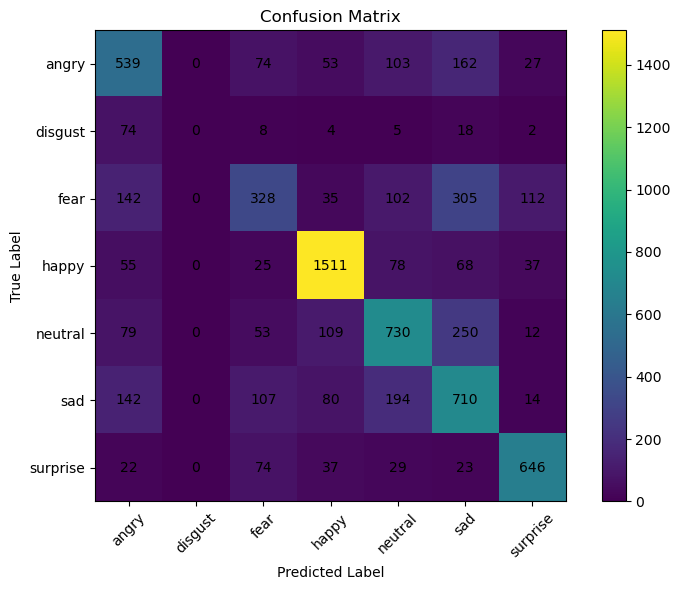

In [32]:
import matplotlib.pyplot as plt
import numpy as np

class_names = test_dataset.classes  # from ImageFolder

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# ---- add numbers inside boxes ----
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [4]:
!dir %USERPROFILE%\.ssh

 Volume in drive C has no label.
 Volume Serial Number is 96D6-8A3D

 Directory of C:\Users\User



File Not Found


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prasadsomvanshih/fer2013-affectnet-dataset-emotions")

print("Path to dataset files:", path)